# Stock Price Prediction Using RNNs

## Objective
The objective of this assignment is to try and predict the stock prices using historical data from four companies IBM (IBM), Google (GOOGL), Amazon (AMZN), and Microsoft (MSFT).

We use four different companies because they belong to the same sector: Technology. Using data from all four companies may improve the performance of the model. This way, we can capture the broader market sentiment.

The problem statement for this assignment can be summarised as follows:

> Given the stock prices of Amazon, Google, IBM, and Microsoft for a set number of days, predict the stock price of these companies after that window.

## Business Value

Data related to stock markets lends itself well to modeling using RNNs due to its sequential nature. We can keep track of opening prices, closing prices, highest prices, and so on for a long period of time as these values are generated every working day. The patterns observed in this data can then be used to predict the future direction in which stock prices are expected to move. Analyzing this data can be interesting in itself, but it also has a financial incentive as accurate predictions can lead to massive profits.

### **Data Description**

You have been provided with four CSV files corresponding to four stocks: AMZN, GOOGL, IBM, and MSFT. The files contain historical data that were gathered from the websites of the stock markets where these companies are listed: NYSE and NASDAQ. The columns in all four files are identical. Let's take a look at them:

- `Date`: The values in this column specify the date on which the values were recorded. In all four files, the dates range from Jaunary 1, 2006 to January 1, 2018.

- `Open`: The values in this column specify the stock price on a given date when the stock market opens.

- `High`: The values in this column specify the highest stock price achieved by a stock on a given date.

- `Low`: The values in this column specify the lowest stock price achieved by a stock on a given date.

- `Close`: The values in this column specify the stock price on a given date when the stock market closes.

- `Volume`: The values in this column specify the total number of shares traded on a given date.

- `Name`: This column gives the official name of the stock as used in the stock market.

There are 3019 records in each data set. The file names are of the format `\<company_name>_stock_data.csv`.

## **1 Data Loading and Preparation** <font color =red> [25 marks] </font>

#### **Import Necessary Libraries**

In [1]:
# Import libraries

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set Keras backend before importing keras or tensorflow
os.environ["KERAS_BACKEND"] = "tensorflow"

import tensorflow as tf
import keras
from keras import Sequential, Input, Model
from keras.layers import Dense, TimeDistributed, LSTM, GRU, Bidirectional, SimpleRNN, RNN

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import shuffle

# Check GPU availability (Apple Metal)
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version:      {keras.__version__}")
print(f"Keras backend:      {keras.backend.backend()}")
print(f"GPUs available:     {tf.config.list_physical_devices('GPU')}")
if tf.config.list_physical_devices('GPU'):
    print("✅ GPU (Apple Metal) will be utilized for training.")
else:
    print("⚠️ No GPU found. Training will use CPU only.")

TensorFlow version: 2.18.0
Keras version:      3.14.1
Keras backend:      tensorflow
GPUs available:     [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU (Apple Metal) will be utilized for training.


### **1.1 Data Aggregation** <font color =red> [7 marks] </font>

As we are using the stock data for four different companies, we need to create a new DataFrame that contains the combined data from all four data frames. We will create a function that takes in a list of the file names for the four CSV files, and returns a single data frame. This function performs the following tasks:
- Extract stock names from file names
- Read the CSV files as data frames
- Append the stock names into the columns of their respective data frames
- Drop unnecessary columns
- Join the data frames into one.

#### **1.1.1** <font color =red> [5 marks] </font>
Create the function to join DataFrames and use it to combine the four datasets.

In [2]:
# Define a function to load data and aggregate them

def load_data(files, directory='../RNN_Stocks_Data'):
    data_frames = []
    for file in files:
        stock_name = file.split('_')[0]  # Extract stock name from filename
        file_path = os.path.join(directory, file)
        df = pd.read_csv(file_path)
        if 'Name' not in df.columns:
            df['Name'] = stock_name
        data_frames.append(df)
    return pd.concat(data_frames, ignore_index=True)


In [3]:
# Specify the names of the raw data files to be read and use the aggregation function to read the files
files = ['AMZN_stocks_data.csv', 'GOOGL_stocks_data.csv', 'IBM_stocks_data.csv', 'MSFT_stocks_data.csv']
stocks_df = load_data(files)



In [4]:
# View specifics of the data
print("Data shape:", stocks_df.shape)
print("\nData types:\n", stocks_df.dtypes)
print("\nData info:\n")
stocks_df.info()
print("\nData sample:\n", stocks_df.head())



Data shape: (12077, 7)

Data types:
 Date          str
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
Name          str
dtype: object

Data info:

<class 'pandas.DataFrame'>
RangeIndex: 12077 entries, 0 to 12076
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    12077 non-null  str    
 1   Open    12076 non-null  float64
 2   High    12077 non-null  float64
 3   Low     12076 non-null  float64
 4   Close   12077 non-null  float64
 5   Volume  12077 non-null  int64  
 6   Name    12077 non-null  str    
dtypes: float64(4), int64(1), str(2)
memory usage: 660.6 KB

Data sample:
          Date   Open   High    Low  Close   Volume  Name
0  2006-01-03  47.47  47.85  46.25  47.58  7582127  AMZN
1  2006-01-04  47.48  47.73  46.69  47.25  7440914  AMZN
2  2006-01-05  47.16  48.20  47.11  47.65  5417258  AMZN
3  2006-01-06  47.97  48.58  47.32  47.87  6154285  AMZN
4  2006-01-09  46.55

#### **1.1.2** <font color =red> [2 marks] </font>
Identify and handle any missing values.

In [5]:
# Handle Missing Values
print("\nMissing values per column:\n", stocks_df.isnull().sum())

# Print the rows with null values
print("\nRows with missing values:\n", stocks_df[stocks_df.isnull().any(axis=1)])



Missing values per column:
 Date      0
Open      1
High      0
Low       1
Close     0
Volume    0
Name      0
dtype: int64

Rows with missing values:
             Date  Open    High  Low   Close   Volume Name
8951  2017-07-31   NaN  144.93  NaN  144.67  4355718  IBM


In [6]:
#Since RNN is dependent on sequence we will not drop this row and would adopt a imutation startegy more suitable for time series data

# impute the Open price with the previous day's Close price
prev_close_grouped = stocks_df.groupby('Name')['Close'].shift(1)
stocks_df['Open'] = stocks_df['Open'].fillna(prev_close_grouped)

#impute the Low
min_open_close = stocks_df[['Open', 'Close']].min(axis=1)
stocks_df['Low'] = stocks_df['Low'].fillna(min_open_close)

In [7]:
print("\nMissing values per column:\n", stocks_df.isnull().sum())


Missing values per column:
 Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
Name      0
dtype: int64


### **1.2 Analysis and Visualisation** <font color =red> [5 marks] </font>

#### **1.2.1** <font color =red> [2 marks] </font>
Analyse the frequency distribution of stock volumes of the companies and also see how the volumes vary over time.

<Figure size 300x200 with 0 Axes>

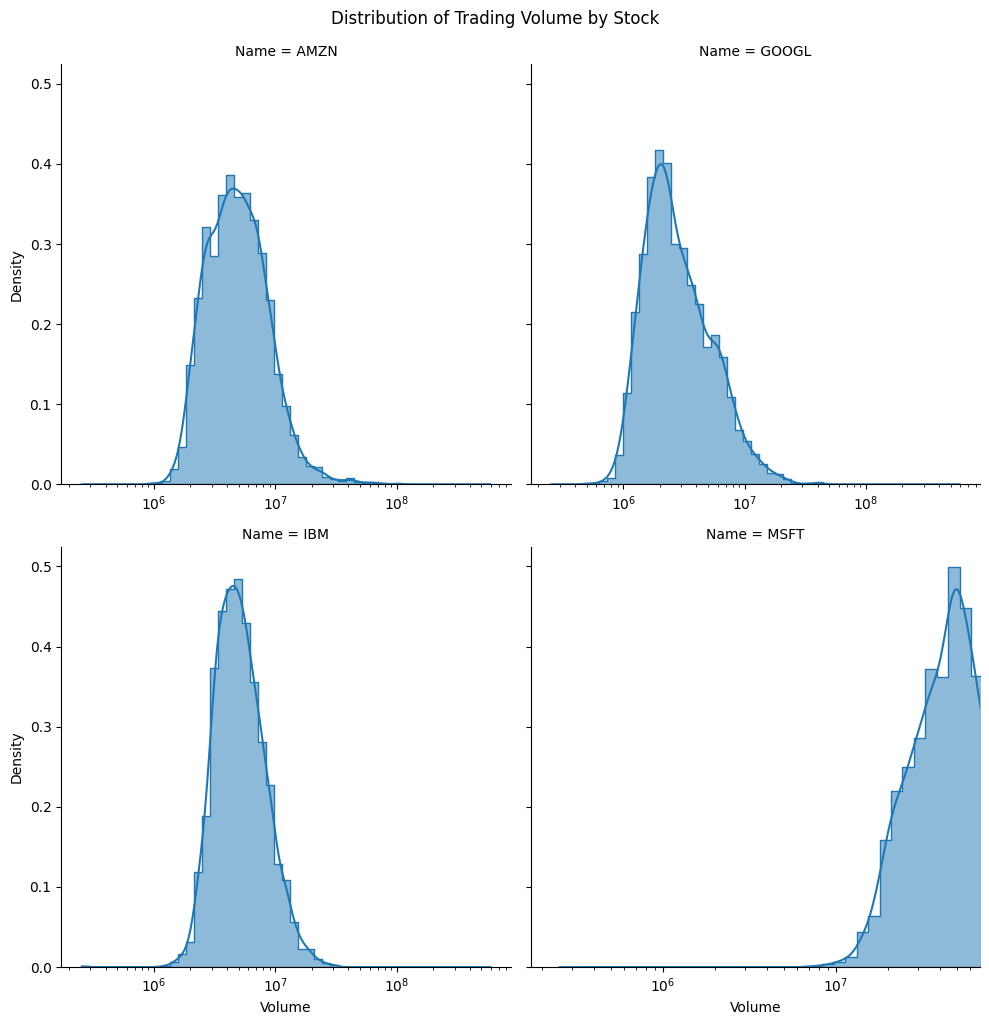

In [18]:
# Frequency distribution of volumes
plt.figure(figsize=(3, 2))
sns.displot(data=stocks_df, x='Volume', col='Name', col_wrap=2, 
            kde=True, facet_kws={'sharex': False}, log_scale=True, element='step', stat='density', palette='Set2')
plt.suptitle('Distribution of Trading Volume by Stock', y=1.02)
plt.xlim(0, stocks_df['Volume'].quantile(0.95))
plt.show()

- MSFT(Microsoft) Daily trading volume [30M-50M] far exceeds other three stocks
- IBM is highly consistent with tight clustering, narrowest and sharpest peak
- Google and Amazon have broader bases, signaling more volatility, more sensitive to earnings and news

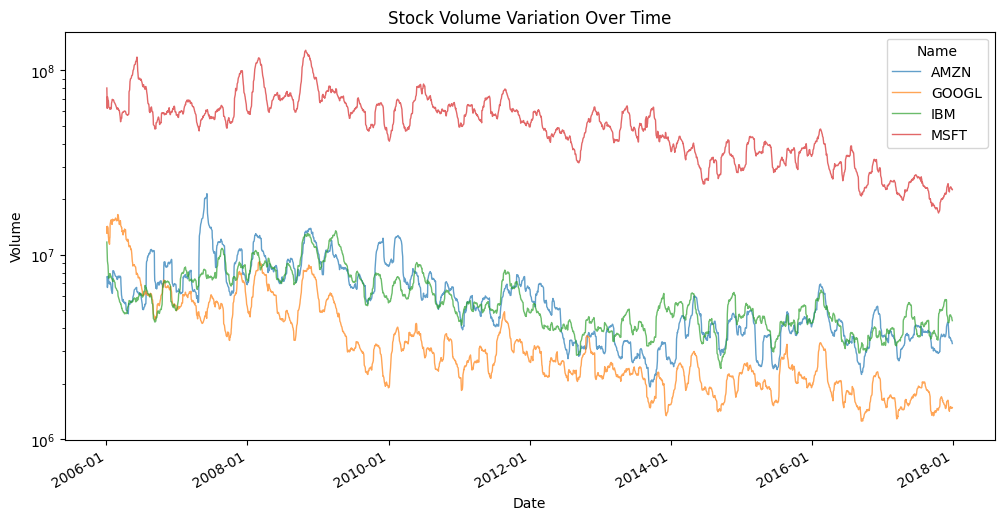

In [22]:
# Stock volume variation over time
import matplotlib.dates as mdates

rolling_df = stocks_df.copy()
rolling_df['Volume'] = rolling_df.groupby('Name')['Volume'].transform(lambda x: x.rolling(window=30, min_periods=1).mean())
rolling_df['Date'] = pd.to_datetime(rolling_df['Date'])

plt.figure(figsize=(12, 6))
sns.lineplot(data=rolling_df, x='Date', y='Volume', hue='Name', linewidth=1, alpha=0.7)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')) # Shows Year-Month
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gcf().autofmt_xdate() # Automatically tilts the dates for readability

plt.title('Stock Volume Variation Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.yscale('log')
plt.show()


- Every stock exhibits a long term downward trend
- Microsoft maintains a massive distinctive lead
- Amazon and IBM share a nearly identical liquidity profile
- All four stocks react to the same macro catalysts [The peaks appear at same time in all 4 stocks volumes]

#### **1.2.2** <font color =red> [3 marks] </font>
Analyse correlations between features.

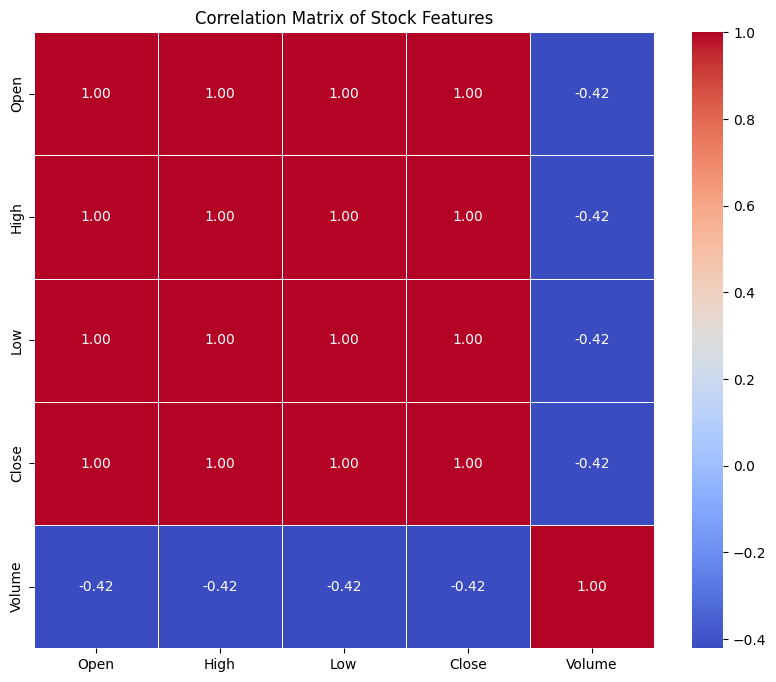

In [24]:
# Analyse correlations
stocks_df_numeric = stocks_df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 8))
sns.heatmap(stocks_df_numeric.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Stock Features')
plt.show()



- The current features show high multicollinearity, meaning `Open`, `Low`, `High`, and `Close` provide very similar information.
- Additional engineered features are needed to better capture daily price behavior and interactions.
  - Log return (Close): `np.log(df['Close'] / df['Close'].shift(1))`
  - Relative high-low spread: `(df['High'] - df['Low']) / df['Close']`
  - Relative gap-up: `(df['Open'] - df['Close'].shift(1)) / df['Close'].shift(1)`
  - Volume change: percentage change or log-transformed volume

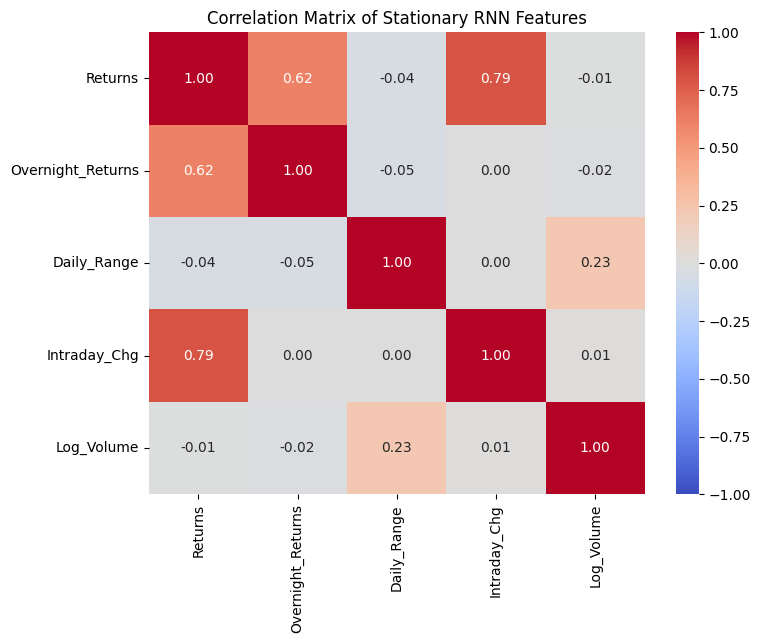

In [29]:
rnn_df = stocks_df.copy()

rnn_df = rnn_df.sort_values(by=['Name', 'Date'])
rnn_df['Prev_Close'] = rnn_df.groupby('Name')['Close'].shift(1)

# 1. Transform raw prices into stationary, meaningful features
rnn_df['Returns'] = np.log(rnn_df['Close'] / rnn_df['Prev_Close'])
rnn_df['Overnight_Returns'] = np.log(rnn_df['Open'] / rnn_df['Prev_Close'])
rnn_df['Daily_Range'] = (rnn_df['High'] - rnn_df['Low']) / rnn_df['Close']
rnn_df['Intraday_Chg'] = (rnn_df['Close'] - rnn_df['Open']) / rnn_df['Open']
rnn_df['Log_Volume'] = np.log(rnn_df['Volume'])

feature_cols = ['Returns', 'Overnight_Returns', 'Daily_Range', 'Intraday_Chg', 'Log_Volume']
rnn_features_clean = rnn_df.dropna(subset=feature_cols)

# 3. Plot the new, highly descriptive correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(rnn_features_clean[feature_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix of Stationary RNN Features')
plt.show()

- There is a highly positive correlation of 0.79 between Returns and Intraday_Chg
    - Intraday_Chg measures price movement from Open to Close, while Returns measures Close to Close (which includes overnight gaps)
    - The 0.79 value shows that a significant portion of a stock’s total daily return is driven by market-hours momentum rather than just overnight news gaps
    - Overnight gap extraction requires a different calculation focusing majorly only on overnight price movement.
    - Because overnight gaps and market hours trading are driven by entirely different mechanics, they have absolutely zero correlation with each other (0.00)
    - Dropping Returns due to high correlation with Overnight_returns

- There is a positive correlation of 0.23 between Daily_Range (volatility) and Log_Volume (liquidity)
    - Higher trading volume directly correlates with a wider daily price spread.
    - This is a classic financial signature: market volume spikes when prices are highly volatile.

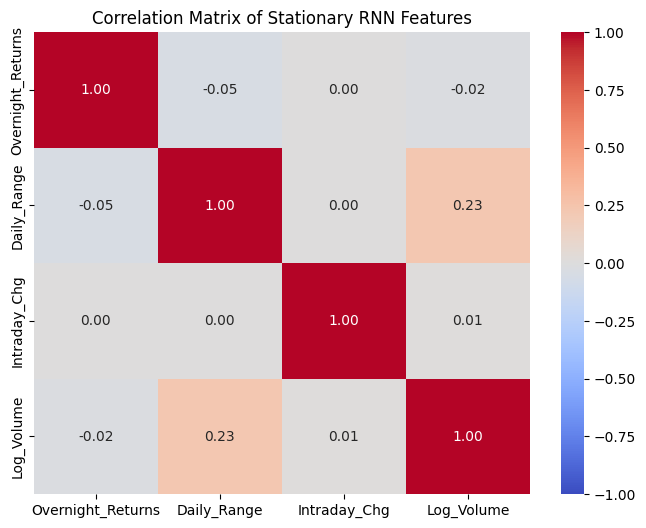

In [30]:
rnn_features_clean.drop(columns=['Returns'], inplace=True)
feature_cols = ['Overnight_Returns', 'Daily_Range', 'Intraday_Chg', 'Log_Volume']

plt.figure(figsize=(8, 6))
sns.heatmap(rnn_features_clean[feature_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix of Stationary RNN Features')
plt.show()

### **1.3 Data Processing** <font color =red> [13 marks] </font>

Next, we need to process the data so that it is ready to be used in recurrent neural networks. You know RNNs are suitable to work with sequential data where patterns repeat at regular intervals.

For this, we need to execute the following steps:
1. Create windows from the master data frame and obtain windowed `X` and corresponding windowed `y` values
2. Perform train-test split on the windowed data
3. Scale the data sets in an appropriate manner

We will define functions for the above steps that finally return training and testing data sets that are ready to be used in recurrent neural networks.

**Hint:** If we use a window of size 3, in the first window, the rows `[0, 1, 2]` will be present and will be used to predict the value of `CloseAMZN` in row `3`. In the second window, rows `[1, 2, 3]` will be used to predict `CloseAMZN` in row `4`.

#### **1.3.1** <font color =red> [3 marks] </font>
Create a function that returns the windowed `X` and `y` data.

From the main DataFrame, this function will create windowed DataFrames, and store those as a list of DataFrames.

Controllable parameters will be window size, step size (window stride length) and target names as a list of the names of stocks whose closing values we wish to predict.

In [ ]:
# Define a function that divides the data into windows and generates target variable values for each window



#### **1.3.2** <font color =red> [3 marks] </font>
Create a function to scale the data.

Define a function that will scale the data.

For scaling, we have to look at the whole length of data to find max/min values or standard deviations and means. If we scale the whole data at once, this will lead to data leakage in the windows. This is not necessarily a problem if the model is trained on the complete data with cross-validation.

One way to scale when dealing with windowed data is to use the `partial_fit()` method.
```
scaler.partial_fit(window)
scaler.transform(window)
```
You may use any other suitable way to scale the data properly. Arrive at a reasonable way to scale your data.

In [ ]:
# Define a function that scales the windowed data
# The function takes in the windowed data sets and returns the scaled windows



Next, define the main function that will call the windowing and scaling helper functions.

The input parameters for this function are:
- The joined master data set
- The names of the stocks that we wish to predict the *Close* prices for
- The window size
- The window stride
- The train-test split ratio

The outputs from this function are the scaled dataframes:
- *X_train*
- *y_train*
- *X_test*
- *y_test*

#### **1.3.3** <font color =red> [3 marks] </font>
Define a function to create windows of `window_size` and split the windowed data in to training and validation sets.

The function can take arguments such as list of target names, window size, window stride and split ratio. Use the windowing function here to make windows in the data and then perform scaling and train-test split.

In [ ]:
# Define a function to create input and output data points from the master DataFrame



We can now use these helper functions to create our training and testing data sets. But first we need to decide on a length of windows. As we are doing time series prediction, we want to pick a sequence that shows some repetition of patterns.

For selecting a good sequence length, some business understanding will help us. In financial scenarios, we can either work with business days, weeks (which comprise of 5 working days), months, or quarters (comprising of 13 business weeks). Try looking for some patterns for these periods.

#### **1.3.4** <font color =red> [2 marks] </font>
Identify an appropriate window size.

For this, you can use plots to see how target variable is varying with time. Try dividing it into parts by weeks/months/quarters.

In [ ]:
# Checking for patterns in different sequence lengths



#### **1.3.5** <font color =red> [2 marks] </font>
Call the functions to create testing and training instances of predictor and target features.

In [ ]:
# Create data instances from the master data frame using decided window size and window stride



In [ ]:
# Check the number of data points generated


**Check if the training and testing datasets are in the proper format to feed into neural networks.**

In [ ]:
# Check if the datasets are compatible inputs to neural networks



## **2 RNN Models** <font color =red> [20 marks] </font>

In this section, we will:
- Define a function that creates a simple RNN
- Tune the RNN for different hyperparameter values
- View the performance of the optimal model on the test data

### **2.1 Simple RNN Model** <font color =red> [10 marks] </font>

#### **2.1.1** <font color =red> [3 marks] </font>
Create a function that builds a simple RNN model based on the layer configuration provided.

In [ ]:
# Create a function that creates a simple RNN model according to the model configuration arguments



#### **2.1.2** <font color =red> [4 marks] </font>
Perform hyperparameter tuning to find the optimal network configuration.

In [ ]:
# Find an optimal configuration of simple RNN



In [ ]:
# Find the best configuration based on evaluation metrics



#### **2.1.3** <font color =red> [3 marks] </font>
Run for optimal Simple RNN Model and show final results.

In [ ]:
# Create an RNN model with a combination of potentially optimal hyperparameter values and retrain the model



Plotting the actual vs predicted values

In [ ]:
# Predict on the test data and plot



It is worth noting that every training session for a neural network is unique. So, the results may vary slightly each time you retrain the model.

In [ ]:
# Compute the performance of the model on the testing data set



### **2.2 Advanced RNN Models** <font color =red> [10 marks] </font>

In this section, we will:
- Create an LSTM or a GRU network
- Tune the network for different hyperparameter values
- View the performance of the optimal model on the test data

#### **2.2.1** <font color =red> [3 marks] </font>
Create a function that builds an advanced RNN model with tunable hyperparameters.

In [ ]:
# # Define a function to create a model and specify default values for hyperparameters



#### **2.2.2** <font color =red> [4 marks] </font>
Perform hyperparameter tuning to find the optimal network configuration.

In [ ]:
# Find an optimal configuration



#### **2.2.3** <font color =red> [3 marks] </font>
Run for optimal RNN Model and show final results.

In [ ]:
# Create the model with a combination of potentially optimal hyperparameter values and retrain the model



In [ ]:
# Compute the performance of the model on the testing data set


Plotting the actual vs predicted values

In [ ]:
# Predict on the test data


## **3 Predicting Multiple Target Variables** <font color =red> [OPTIONAL] </font>

In this section, we will use recurrent neural networks to predict stock prices for more than one company.

### **3.1 Data Preparation**

#### **3.1.1**
Create testing and training instances for multiple target features.

You can take the closing price of all four companies to predict here.

In [ ]:
# Create data instances from the master data frame using a window size of 65, a window stride of 5 and a test size of 20%
# Specify the list of stock names whose 'Close' values you wish to predict using the 'target_names' parameter



In [ ]:
# Check the number of data points generated



### **3.2 Run RNN Models**

#### **3.2.1**
Perform hyperparameter tuning to find the optimal network configuration for Simple RNN model.

In [ ]:
# Find an optimal configuration of simple RNN



In [ ]:
# Find the best configuration



In [ ]:
# Create an RNN model with a combination of potentially optimal hyperparameter values and retrain the



In [ ]:
# Compute the performance of the model on the testing data set



In [ ]:
# Plotting the actual vs predicted values for all targets



#### **3.2.2**
Perform hyperparameter tuning to find the optimal network configuration for Advanced RNN model.

In [ ]:
# Find an optimal configuration of advanced RNN



In [ ]:
# Find the best configuration



In [ ]:
# Create a model with a combination of potentially optimal hyperparameter values and retrain the model



In [ ]:
# Compute the performance of the model on the testing data set



In [ ]:
# Plotting the actual vs predicted values for all targets



## **4 Conclusion** <font color =red> [5 marks] </font>

### **4.1 Conclusion and insights** <font color =red> [5 marks] </font>

#### **4.1.1** <font color =red> [5 marks] </font>
Conclude with the insights drawn and final outcomes and results.